# EDA Notebook

## 1. Importar librerías necesarias
Importar pandas, numpy, matplotlib y seaborn para el análisis y visualización de datos.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium as fl
import nltk as nt


## 2. Cargar el archivo CSV
Solicitar al usuario la ruta del archivo .csv y cargarlo en un DataFrame de pandas.

In [4]:
import os

# Change this path to point to your data file
file_path = 'data/raw/Hotel_Reviews.csv'

possible_paths = [
	file_path,
	'Hotel_Reviews.csv',
	'data/Hotel_Reviews.csv',
	'../data/raw/Hotel_Reviews.csv',
	'./data/raw/Hotel_Reviews.csv',
]

for path in possible_paths:
	if os.path.exists(path):
		file_path = path
		break

if not os.path.exists(file_path):
	raise FileNotFoundError(
		f"File not found: {file_path}. "
		"Please verify the dataset location or move the CSV to one of the expected paths."
	)

df = pd.read_csv(file_path)

## 3. Visualizar las primeras filas del dataset
Mostrar las primeras filas del DataFrame usando head() para obtener una vista general de los datos.

In [6]:
df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


## 4. Explorar información general del dataset
Utilizar info() y shape para mostrar información sobre el número de filas, columnas y tipos de datos.

In [5]:
df.info()
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

<class 'pandas.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  str    
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  str    
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  str    
 5   Reviewer_Nationality                        515738 non-null  str    
 6   Negative_Review                             515738 non-null  str    
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  str    
 10  Review_

## 5. Describir variables numéricas y categóricas
Usar describe() para variables numéricas y value_counts() para variables categóricas.

In [15]:
# Numerical variables
#df.describe()
#obtenemos las 20 nacionalidades que más comentan
nationalities_most_commented = df['Reviewer_Nationality'].value_counts().head(20)
display(nationalities_most_commented)

Reviewer_Nationality
United Kingdom               245246
United States of America      35437
Australia                     21686
Ireland                       14827
United Arab Emirates          10235
Saudi Arabia                   8951
Netherlands                    8772
Switzerland                    8678
Germany                        7941
Canada                         7894
France                         7296
Israel                         6610
Italy                          6114
Belgium                        6031
Turkey                         5444
Kuwait                         4920
Spain                          4737
Romania                        4552
Russia                         3900
South Africa                   3821
Name: count, dtype: int64

## 6. Visualizar valores nulos y duplicados
Identificar y visualizar la cantidad de valores nulos y filas duplicadas en el dataset.

In [11]:
# Null values
print("VALORES NULOS: \n",df.isnull().sum())

# Duplicated rows
print("REGISTROS DUPLICADOS ",df.duplicated().sum())

VALORES NULOS: 
 Hotel_Address                                    0
Additional_Number_of_Scoring                     0
Review_Date                                      0
Average_Score                                    0
Hotel_Name                                       0
Reviewer_Nationality                             0
Negative_Review                                  0
Review_Total_Negative_Word_Counts                0
Total_Number_of_Reviews                          0
Positive_Review                                  0
Review_Total_Positive_Word_Counts                0
Total_Number_of_Reviews_Reviewer_Has_Given       0
Reviewer_Score                                   0
Tags                                             0
days_since_review                                0
lat                                           3268
lng                                           3268
dtype: int64
REGISTROS DUPLICADOS  526


## 7. Análisis univariado de variables numéricas
Realizar histogramas y boxplots para analizar la distribución de las variables numéricas.

<Axes: >

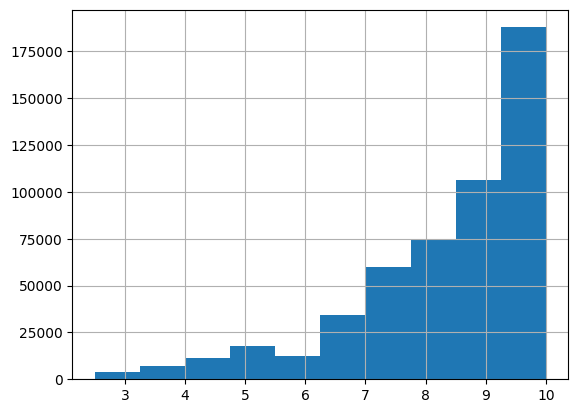

In [13]:
# Histogram for a numerical variable
# df['numeric_column'].hist()
plt.show()

df['Reviewer_Score'].hist()

# Boxplot
# df.boxplot(column='numeric_column')
# plt.show()

Aquí estamos viendo que las quejas son eventos menos comunes pero más drásticos.

## 8. Análisis univariado de variables categóricas
Realizar gráficos de barras para analizar la frecuencia de las variables categóricas.

In [ ]:
# Bar plot for a categorical variable
# df['categorical_column'].value_counts().plot(kind='bar')
# plt.show()

## 9. Análisis bivariado entre variables
Explorar relaciones entre variables numéricas y categóricas mediante scatterplots y tablas cruzadas.

In [ ]:
# Scatterplot
# plt.scatter(df['numeric_column_x'], df['numeric_column_y'])
# plt.show()

# Crosstab for two categorical variables   
# pd.crosstab(df['categorical_column1'], df['categorical_column2'])

## 10. Visualización de correlaciones
Calcular y visualizar la matriz de correlación entre variables numéricas usando un heatmap.

In [ ]:
# Correlation matrix
corr = df.corr()
sns.heatmap(corr, annot=True)
plt.show()